Mounted at /content/drive
Granularité native  : 69888 pas (15 min)
Granularité horaire : 17472 pas (1h)
Entraînement : 8760 pas (365 jours)
Simulation   : 120 pas (5 jours)
[Forecaster] Entraînement consommation...
[Forecaster] Prêt.

=== Mode Réactif (conso Prophet + gen réelle) — pas horaire ===
Pas simulés : 120 | Ré-opt. : 120

=== Mode Oracle (tout réel) ===

╔══════════════════════════════════════════╗
║          TABLEAU COMPARATIF KPI          ║
╚══════════════════════════════════════════╝
                    Prévisions (Prophet)  Connaissance parfaite
KPI                                                            
total_cost_EUR                    2.7350                 1.4977
energy_bought_kWh                60.7420                50.5100
energy_sold_kWh                  40.8020                31.0370
baseline_cost_EUR                 8.1643                 8.1643
savings_EUR                       5.4293                 6.6666
savings_pct                      66.5000          

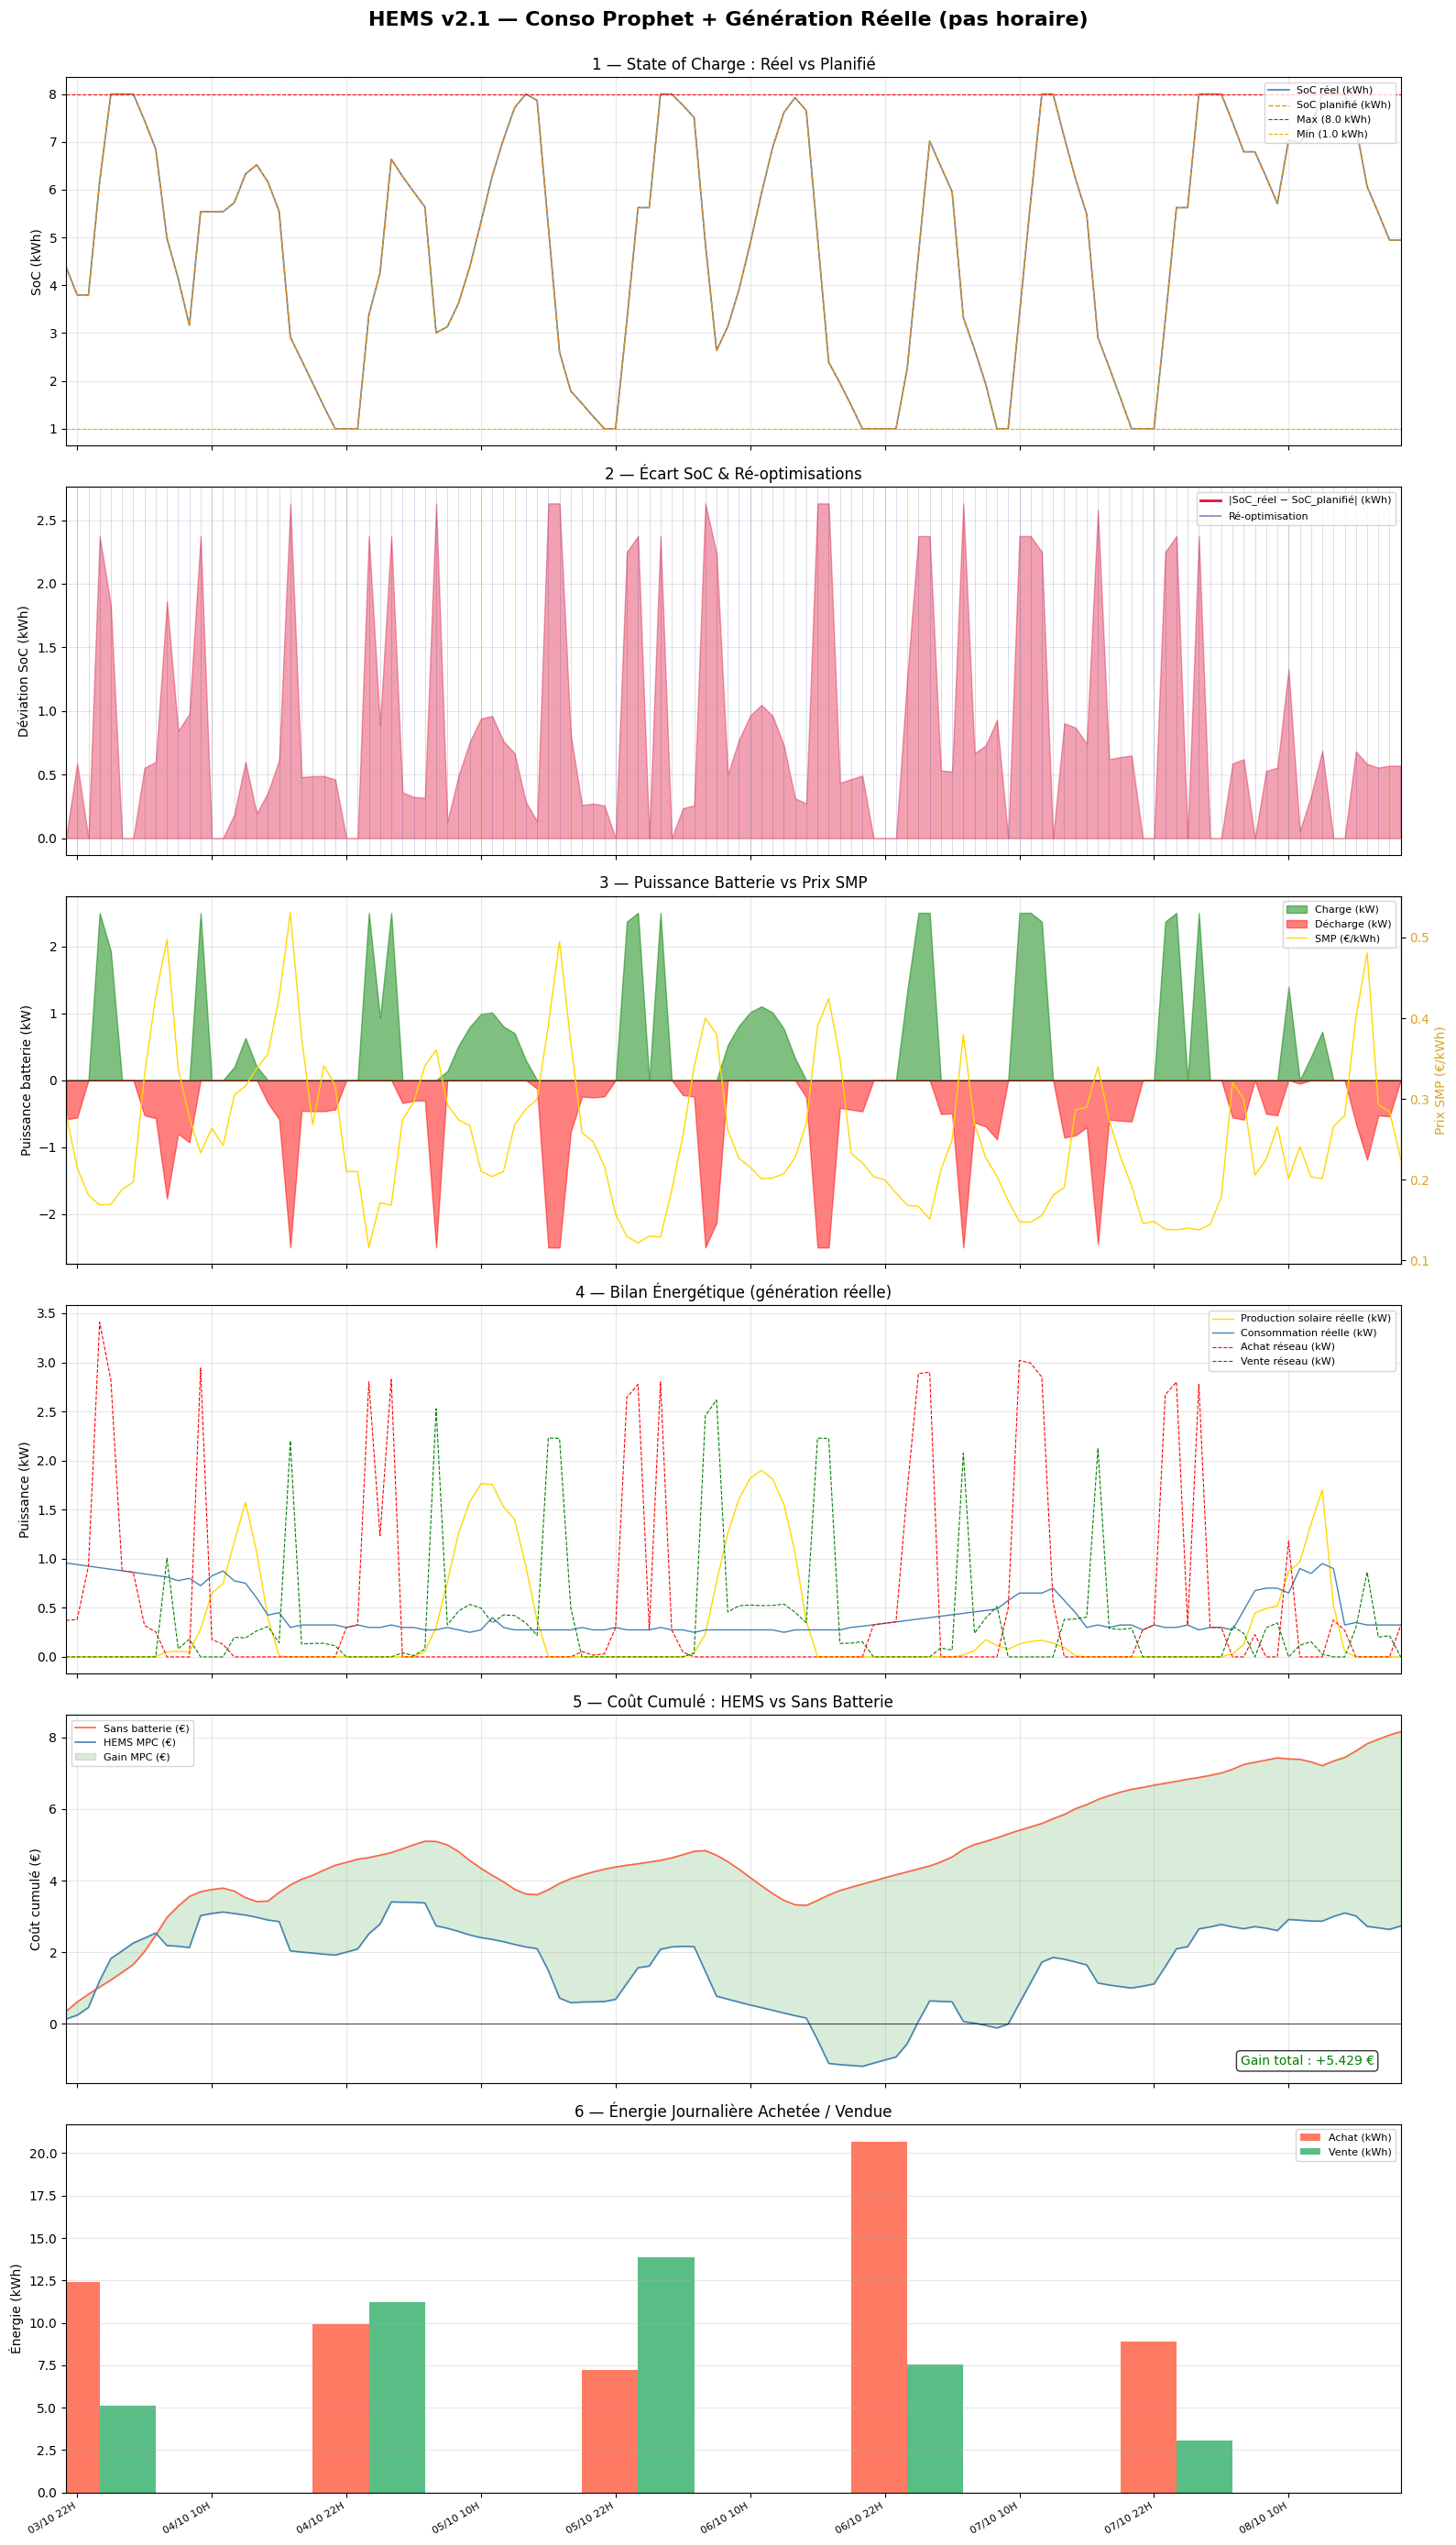

[Viz] Sauvegardé : hems_comparison_v2_1_hourly.png


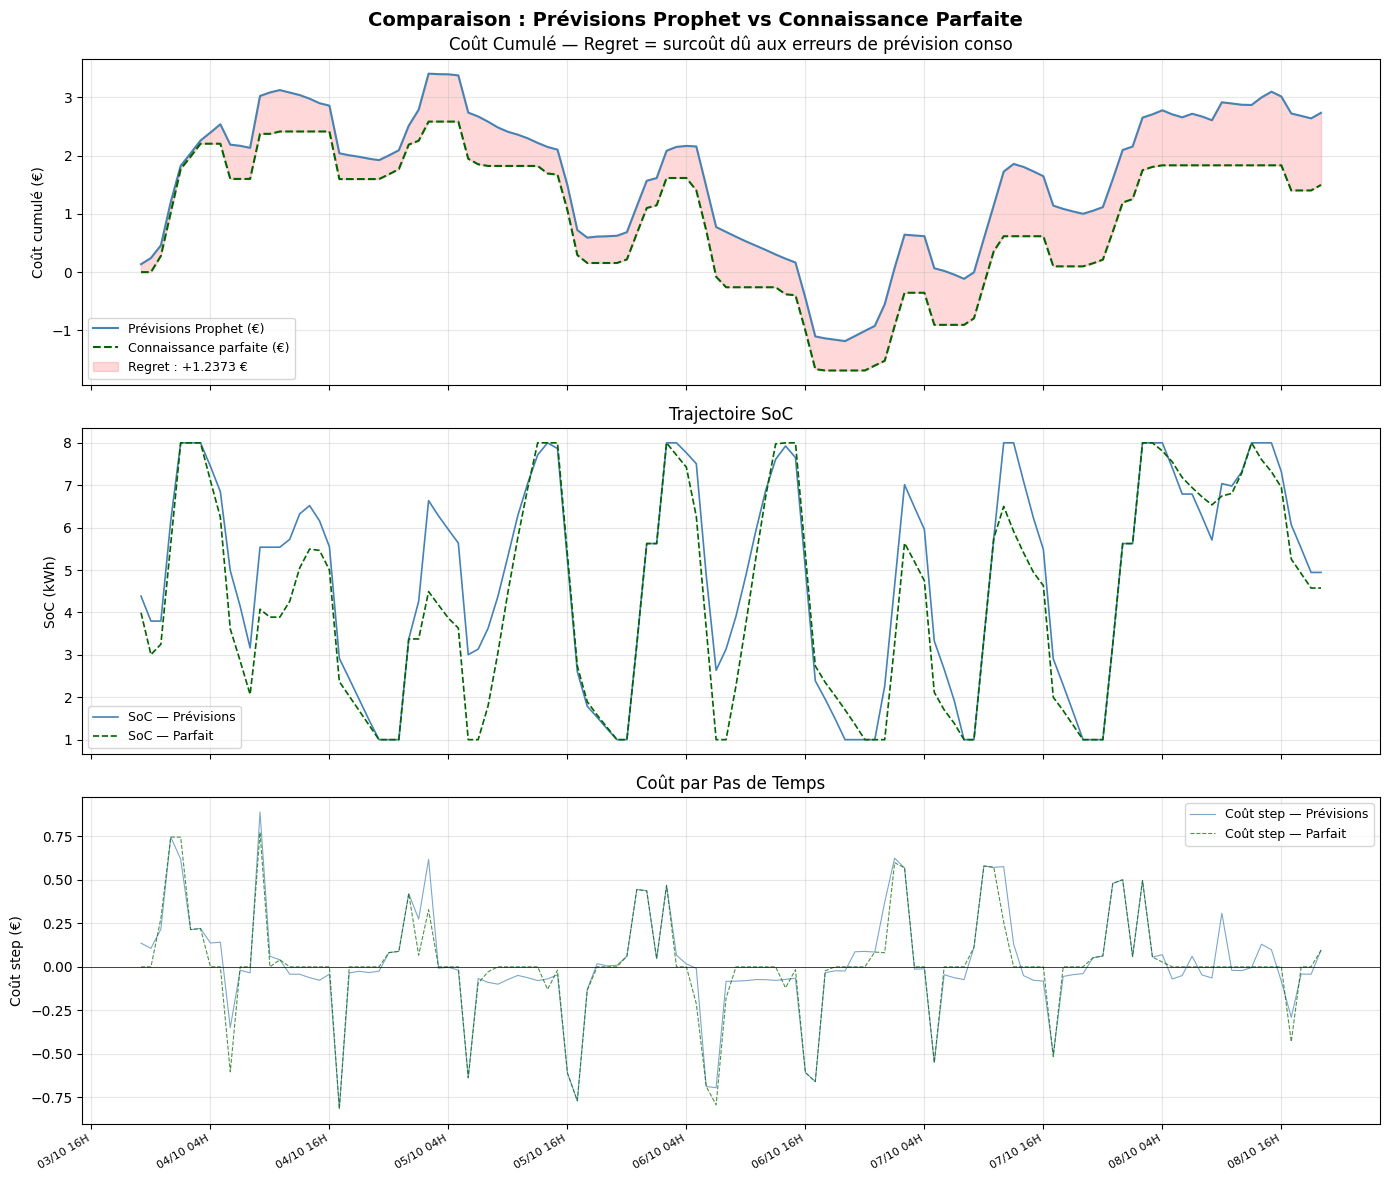

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import pulp
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

def resample_hourly(df: pd.DataFrame, freq: str = "1h") -> pd.DataFrame:
    cols = ["SMP", "Energy_Generation", "Energy_Consumption"]
    df_h = df[cols].resample(freq).mean().dropna()
    return df_h

# 1 — EnergyForecaster

class EnergyForecaster:
    """
    Prévision de la consommation domestique via Facebook Prophet.
    La génération solaire est lue directement depuis les données réelles.

    Utilisation :
        fc = EnergyForecaster()
        fc.fit(df_train, "Energy_Consumption")
        prev = fc.predict_next_day(anchor_ts, horizon_steps=24)
        # prev.columns : ds | yhat_con
    """

    def __init__(self):
        # Un seul modèle : consommation (saisonnalité additive)
        self.model_con = Prophet(
            seasonality_mode="additive",
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=False,
            changepoint_prior_scale=0.05,
        )
        self._fitted = False

    @staticmethod
    def _to_prophet_df(series: pd.Series) -> pd.DataFrame:
        """Convertit une Series DatetimeIndex → format Prophet (ds, y)."""
        df = series.reset_index()
        df.columns = ["ds", "y"]
        df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None)
        df["y"]  = df["y"].clip(lower=0)
        return df

    def fit(self, df: pd.DataFrame, col_con: str) -> None:
        """
        Entraîne le modèle Prophet sur les données historiques.

        Paramètres
        ----------
        df      : DataFrame avec DatetimeIndex (résolution horaire)
        col_con : nom de la colonne consommation (kW)
        """
        print("[Forecaster] Entraînement consommation...")
        self.model_con.fit(self._to_prophet_df(df[col_con]))
        self._fitted = True
        print("[Forecaster] Prêt.")

    def predict_next_day(self,
                          anchor_ts: pd.Timestamp,
                          horizon_steps: int = 24,
                          freq: str = "1h") -> pd.DataFrame:
        """
        Prévision de `horizon_steps` pas à partir de `anchor_ts`.

        Retourne
        --------
        pd.DataFrame avec colonnes : ds | yhat_con
        """
        if not self._fitted:
            raise RuntimeError("Appeler .fit() avant de prédire.")

        ts = anchor_ts.tz_localize(None) if anchor_ts.tzinfo else anchor_ts
        future = pd.DataFrame({"ds": pd.date_range(ts, periods=horizon_steps, freq=freq)})

        fc_con = self.model_con.predict(future)[["ds", "yhat"]].rename(columns={"yhat": "yhat_con"})
        fc_con["yhat_con"] = fc_con["yhat_con"].clip(lower=0)
        return fc_con


# 2 — MILPScheduler (inchangée — paramétrée par delta_t)

class MILPScheduler:

    def __init__(self,
                 battery_cap:  float = 10.0,
                 soc_min_pct:  float = 0.10,
                 soc_max_pct:  float = 0.80,
                 p_max:        float = 1.5,
                 eff:          float = 0.95,
                 delta_t:      float = 1.0,
                 buy_premium:  float = 1.30,   # achat = SMP × 1.30
                 sell_discount:float = 0.70):
        self.battery_cap = battery_cap
        self.soc_min  = battery_cap * soc_min_pct
        self.soc_max  = battery_cap * soc_max_pct
        self.p_max    = p_max
        self.eff      = eff
        self.delta_t  = delta_t
        self.buy_premium   = buy_premium
        self.sell_discount = sell_discount

    def solve(self,
              soc_init:     float,
              c_smp:        list,
              p_gen:        list,
              p_con:        list,
              terminal_soc: float | None = None) -> dict:

        H    = len(c_smp)
        soc0 = terminal_soc if terminal_soc is not None else soc_init

        mdl = pulp.LpProblem("MILP_HEMS", pulp.LpMinimize)

        x_ch   = pulp.LpVariable.dicts("ch",   range(H), lowBound=0, upBound=self.p_max)
        x_dis  = pulp.LpVariable.dicts("dis",  range(H), lowBound=0, upBound=self.p_max)
        p_buy  = pulp.LpVariable.dicts("buy",  range(H), lowBound=0)
        p_sell = pulp.LpVariable.dicts("sell", range(H), lowBound=0)
        SoC    = pulp.LpVariable.dicts("soc",  range(H),
                                        lowBound=self.soc_min,
                                        upBound=self.soc_max)
        d_ch   = pulp.LpVariable.dicts("dch",  range(H), cat="Binary")
        d_dis  = pulp.LpVariable.dicts("ddis", range(H), cat="Binary")

        # Objectif : minimiser coût net d'échange
        mdl += pulp.lpSum(
            p_buy[t]  * c_smp[t] * self.buy_premium   * self.delta_t
             - p_sell[t] * c_smp[t] * self.sell_discount * self.delta_t
        for t in range(H)
        ), "MinCoutNet"

        for t in range(H):
            soc_prev = soc_init if t == 0 else SoC[t - 1]

            # (C1) Bilan de puissance
            mdl += (p_con[t] + x_ch[t] + p_sell[t] == p_gen[t] + x_dis[t] + p_buy[t]), f"bilan_{t}"

            # (C2) Exclusion mutuelle
            mdl += d_ch[t] + d_dis[t] <= 1, f"mutex_{t}"

            # (C3) Borne charge
            mdl += x_ch[t]  <= self.p_max * d_ch[t],  f"ch_bound_{t}"

            # (C4) Borne décharge
            mdl += x_dis[t] <= self.p_max * d_dis[t], f"dis_bound_{t}"

            # (C5) Dynamique SoC
            mdl += (SoC[t] == soc_prev
                    + (x_ch[t] * self.eff - x_dis[t] / self.eff) * self.delta_t), f"soc_dyn_{t}"

        # (C6) Contrainte terminale
        mdl += SoC[H - 1] >= soc0, "terminal"

        mdl.solve(pulp.PULP_CBC_CMD(msg=0))
        status = pulp.LpStatus[mdl.status]

        if status != "Optimal":
            return {
                "status":   status,
                "x_ch":     [0.0] * H, "x_dis":    [0.0] * H,
                "p_buy":    [0.0] * H, "p_sell":   [0.0] * H,
                "soc_plan": [soc_init] * H, "cost": 0.0,
            }

        return {
            "status":   status,
            "x_ch":     [pulp.value(x_ch[t])   or 0.0 for t in range(H)],
            "x_dis":    [pulp.value(x_dis[t])  or 0.0 for t in range(H)],
            "p_buy":    [pulp.value(p_buy[t])  or 0.0 for t in range(H)],
            "p_sell":   [pulp.value(p_sell[t]) or 0.0 for t in range(H)],
            "soc_plan": [pulp.value(SoC[t])    or 0.0 for t in range(H)],
            "cost":     pulp.value(mdl.objective) or 0.0,
        }

# 3 — ReactiveController


class ReactiveController:

    def __init__(self,
                 scheduler:               MILPScheduler,
                 forecaster:              EnergyForecaster,
                 real_data:               pd.DataFrame,
                 soc_init:                float = 10.0,
                 horizon_steps:           int   = 24,
                 soc_deviation_threshold: float = 0.5,
                 reoptimize_every:        int   = 1):
        self.sched    = scheduler
        self.fc       = forecaster
        self.data     = real_data
        self.soc0     = soc_init
        self.H        = horizon_steps
        self.dev_thr  = soc_deviation_threshold
        self.reopt_n  = reoptimize_every
        self._fc_cache: dict = {}

    # Helpers

    def _real_slice(self, k: int, h: int) -> tuple:
        """
        Tranche entièrement réelle : SMP, génération, consommation.
        Utilisée en mode oracle (use_forecast=False).
        """
        sl = self.data.iloc[k : k + h]
        return (
            sl["SMP"].tolist(),
            sl["Energy_Generation"].tolist(),
            sl["Energy_Consumption"].tolist(),
        )

    def _forecast_slice(self, k: int, h: int) -> tuple:
        """
        Tranche mixte :
          - SMP         : réel  (observable day-ahead)
          - Génération  : réelle (capteur PV ou courbe connue)
          - Consommation: prévision Prophet (seule source d'incertitude)

        Cache multi-jours (J et J+1) pour éviter le padding
        répété quand l'horizon déborde de minuit.
        """
        day_idx    = k // self.H
        day_offset = k %  self.H

        # Génère les prévisions pour le jour courant ET le suivant
        for d in [day_idx, day_idx + 1]:
            if d not in self._fc_cache:
                start_k = d * self.H
                if start_k < len(self.data):
                    anchor = self.data.index[start_k]
                    self._fc_cache[d] = self.fc.predict_next_day(anchor, self.H)

        # Tranche du jour courant
        fc_today = self._fc_cache[day_idx]
        fc_sl    = fc_today.iloc[day_offset : day_offset + h].reset_index(drop=True)

        # Complément sur le jour suivant si l'horizon déborde de minuit
        if len(fc_sl) < h and (day_idx + 1) in self._fc_cache:
            manque      = h - len(fc_sl)
            fc_tomorrow = self._fc_cache[day_idx + 1]
            fc_suite    = fc_tomorrow.iloc[:manque].reset_index(drop=True)
            fc_sl       = pd.concat([fc_sl, fc_suite], ignore_index=True)

        # Repli ultime : dernier jour de simulation (pas de J+1 disponible)
        if len(fc_sl) < h:
            pad  = h - len(fc_sl)
            last = fc_sl.iloc[[-1]]
            fc_sl = pd.concat([fc_sl] + [last] * pad, ignore_index=True)

        # SMP et génération : toujours les valeurs réelles du CSV
        c_smp_real = self.data["SMP"].iloc[k : k + h].tolist()
        p_gen_real = self.data["Energy_Generation"].iloc[k : k + h].tolist()

        # Consommation : prévision Prophet uniquement
        p_con_fc   = fc_sl["yhat_con"].tolist()

        return c_smp_real, p_gen_real, p_con_fc

    # Boucle principale

    def run(self, num_days: int = 5, use_forecast: bool = True) -> pd.DataFrame:
        """
        Simulation en mode recul glissant.

        use_forecast=True  → consommation Prophet + génération réelle
        use_forecast=False → tout réel (oracle, borne inférieure)
        """
        T_total  = min(num_days * self.H, len(self.data))
        soc_cur  = self.soc0
        plan     = None
        plan_pos = 0
        history  = []

        for k in range(T_total):
            horizon = min(self.H, T_total - k, len(self.data) - k)
            if horizon <= 0:
                break

            # Écart SoC
            soc_dev = 0.0
            if plan is not None and plan_pos < len(plan["soc_plan"]):
                soc_dev = abs(soc_cur - plan["soc_plan"][plan_pos])

            # Décision de ré-optimisation
            need_reopt = (
                plan is None
                or plan_pos >= len(plan["x_ch"])
                or k % self.reopt_n == 0
                or soc_dev > self.dev_thr
            )

            if need_reopt:
                fn = self._forecast_slice if use_forecast else self._real_slice
                c_smp, p_gen_h, p_con_h = fn(k, horizon)
                plan     = self.sched.solve(soc_cur, c_smp, p_gen_h, p_con_h)
                plan_pos = 0

            # Actions batterie issues du plan
            act_ch  = plan["x_ch"][plan_pos]
            act_dis = plan["x_dis"][plan_pos]

            # Données réelles du pas courant
            real_smp = self.data["SMP"].iloc[k]
            real_gen = self.data["Energy_Generation"].iloc[k]
            real_con = self.data["Energy_Consumption"].iloc[k]

            # Bilan réseau réel : la génération réelle et la conso réelle
            # équilibrent le réseau — seules les actions batterie viennent du plan
            p_net_real = real_con + act_ch - real_gen - act_dis
            if p_net_real > 0:
                act_buy  = p_net_real
                act_sell = 0.0
            else:
                act_buy  = 0.0
                act_sell = -p_net_real

            # Mise à jour SoC réel
            delta_soc = (act_ch * self.sched.eff - act_dis / self.sched.eff) * self.sched.delta_t
            soc_cur   = float(np.clip(
                soc_cur + delta_soc,
                self.sched.soc_min,
                self.sched.soc_max,
            ))

            step_cost = (act_buy  * real_smp * self.sched.buy_premium- act_sell * real_smp * self.sched.sell_discount) * self.sched.delta_t

            history.append({
                "Timestamp":     self.data.index[k],
                "Price_SMP":     real_smp,
                "Solar_Gen":     real_gen,
                "Consumption":   real_con,
                "SoC_kWh":       soc_cur,
                "SoC_Planned":   plan["soc_plan"][plan_pos],
                "SoC_Deviation": soc_dev,
                "Charge_kW":     act_ch,
                "Discharge_kW":  act_dis,
                "Buy_kW":        act_buy,
                "Sell_kW":       act_sell,
                "Step_Cost_EUR": step_cost,
                "Reoptimized":   int(need_reopt),
            })
            plan_pos += 1

        return pd.DataFrame(history).set_index("Timestamp")



# 4 — KPITracker


class KPITracker:

    @staticmethod
    def compute(df: pd.DataFrame, delta_t: float = 1.0, buy_premium:  float = 1.30, sell_discount:float = 0.70) -> dict:
        total_cost    = df["Step_Cost_EUR"].sum()
        energy_bought = (df["Buy_kW"]  * delta_t).sum()
        energy_sold   = (df["Sell_kW"] * delta_t).sum()

        buy_nb  = np.maximum(0, df["Consumption"] - df["Solar_Gen"])
        sell_nb = np.maximum(0, df["Solar_Gen"]   - df["Consumption"])
        cost_nb = (buy_nb  * df["Price_SMP"] * buy_premium- sell_nb * df["Price_SMP"] * sell_discount).multiply(delta_t).sum()

        savings     = cost_nb - total_cost
        savings_pct = 100 * savings / abs(cost_nb) if cost_nb != 0 else 0.0

        total_con = (df["Consumption"] * delta_t).sum()
        total_gen = (df["Solar_Gen"]   * delta_t).sum()
        self_suff = 100 * (1 - energy_bought / total_con) if total_con > 0 else 0.0
        self_cons = 100 * (1 - energy_sold   / total_gen) if total_gen > 0 else 0.0

        avg_soc = df["SoC_kWh"].mean()
        n_reopt = int(df["Reoptimized"].sum()) if "Reoptimized" in df.columns else 0
        avg_dev = df["SoC_Deviation"].mean()   if "SoC_Deviation" in df.columns else 0.0

        return {
            "total_cost_EUR":     round(total_cost, 4),
            "energy_bought_kWh":  round(energy_bought, 3),
            "energy_sold_kWh":    round(energy_sold, 3),
            "baseline_cost_EUR":  round(cost_nb, 4),
            "savings_EUR":        round(savings, 4),
            "savings_pct":        round(savings_pct, 2),
            "self_sufficiency_%": round(self_suff, 2),
            "self_consumption_%": round(self_cons, 2),
            "avg_SoC_kWh":        round(avg_soc, 3),
            "n_reoptimizations":  n_reopt,
            "avg_SoC_deviation":  round(avg_dev, 4),
        }

    @staticmethod
    def compare(df_fc: pd.DataFrame,
                df_pk: pd.DataFrame,
                delta_t: float = 1.0,  buy_premium:  float = 1.30, sell_discount:float = 0.70) -> pd.DataFrame:
        kpi_fc = KPITracker.compute(df_fc, delta_t, buy_premium, sell_discount)
        kpi_pk = KPITracker.compute(df_pk, delta_t, buy_premium, sell_discount)
        regret = kpi_fc["total_cost_EUR"] - kpi_pk["total_cost_EUR"]

        rows = [{"KPI": k,
                 "Prévisions (Prophet)":  kpi_fc[k],
                 "Connaissance parfaite": kpi_pk[k]}
                for k in kpi_fc]
        rows.append({
            "KPI":                   "regret_EUR",
            "Prévisions (Prophet)":  round(regret, 4),
            "Connaissance parfaite": 0.0,
        })
        return pd.DataFrame(rows).set_index("KPI")

    @staticmethod
    def forecast_accuracy(df_results: pd.DataFrame,
                          df_forecast: pd.DataFrame) -> dict:
        """
        Précision Prophet sur la consommation uniquement.
        La génération n'est plus prévue en v2.
        """
        fc = df_forecast.copy()
        fc["ds"] = pd.to_datetime(fc["ds"]).dt.tz_localize(None)
        fc = fc.set_index("ds")

        res = df_results.copy()
        if res.index.tzinfo:
            res.index = res.index.tz_localize(None)

        merged = res.join(fc[["yhat_con"]], how="inner")
        if merged.empty:
            return {"erreur": "Aucun timestamp commun entre prévisions et résultats."}

        def mape(y, yhat):
            mask = y > 0
            return float(100 * np.mean(np.abs((y[mask] - yhat[mask]) / y[mask])))

        def rmse(y, yhat):
            return float(np.sqrt(mean_squared_error(y, yhat)))

        return {
            "con_MAE":    round(mean_absolute_error(merged["Consumption"], merged["yhat_con"]), 4),
            "con_RMSE":   round(rmse(merged["Consumption"].values, merged["yhat_con"].values), 4),
            "con_MAPE_%": round(mape(merged["Consumption"].values, merged["yhat_con"].values), 2),
        }


# 5 — HEMSVisualizer

class HEMSVisualizer:

    @staticmethod
    def plot_simulation(df: pd.DataFrame,
                        title: str     = "HEMS — Analyse MILP Réactive",
                        soc_max: float = 16.0,
                        soc_min: float = 2.0,
                        delta_t: float = 1.0,
                        buy_premium: float = 1.30,
                        sell_discount: float = 0.70,
                        save_path: str = None):

        fig, axes = plt.subplots(6, 1, figsize=(16, 28), sharex=True)
        fig.suptitle(title, fontsize=16, fontweight="bold", y=0.99)
        t = df.index

        ax = axes[0]
        ax.plot(t, df["SoC_kWh"],     color="steelblue",  lw=1.2, label="SoC réel (kWh)")
        ax.plot(t, df["SoC_Planned"], color="darkorange", lw=1.0, ls="--", label="SoC planifié (kWh)")
        ax.axhline(soc_max, color="red",    ls="--", lw=0.8, label=f"Max ({soc_max} kWh)")
        ax.axhline(soc_min, color="orange", ls="--", lw=0.8, label=f"Min ({soc_min} kWh)")
        ax.set_ylabel("SoC (kWh)")
        ax.set_title("1 — State of Charge : Réel vs Planifié")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        ax.fill_between(t, df["SoC_Deviation"], alpha=0.4, color="crimson")
        for rt in df[df["Reoptimized"] == 1].index:
            ax.axvline(rt, color="navy", alpha=0.2, lw=0.5)
        ax.legend(handles=[
            Line2D([0], [0], color="crimson", lw=2,   label="|SoC_réel − SoC_planifié| (kWh)"),
            Line2D([0], [0], color="navy",    lw=1.5, alpha=0.4, label="Ré-optimisation"),
        ], fontsize=8)
        ax.set_ylabel("Déviation SoC (kWh)")
        ax.set_title("2 — Écart SoC & Ré-optimisations")
        ax.grid(True, alpha=0.3)

        ax   = axes[2]
        ax_t = ax.twinx()
        ax.fill_between(t,  df["Charge_kW"],    alpha=0.5, color="green", label="Charge (kW)")
        ax.fill_between(t, -df["Discharge_kW"], alpha=0.5, color="red",   label="Décharge (kW)")
        ax.axhline(0, color="black", lw=0.5)
        ax_t.plot(t, df["Price_SMP"], color="gold", lw=1.0, label="SMP (€/kWh)")
        ax_t.set_ylabel("Prix SMP (€/kWh)", color="goldenrod")
        ax_t.tick_params(axis="y", labelcolor="goldenrod")
        l1, lb1 = ax.get_legend_handles_labels()
        l2, lb2 = ax_t.get_legend_handles_labels()
        ax.legend(l1 + l2, lb1 + lb2, fontsize=8)
        ax.set_ylabel("Puissance batterie (kW)")
        ax.set_title("3 — Puissance Batterie vs Prix SMP")
        ax.grid(True, alpha=0.3)

        ax = axes[3]
        ax.plot(t, df["Solar_Gen"],   color="gold",      lw=1.0, label="Production solaire réelle (kW)")
        ax.plot(t, df["Consumption"], color="steelblue", lw=1.0, label="Consommation réelle (kW)")
        ax.plot(t, df["Buy_kW"],      color="red",       lw=0.8, ls="--", label="Achat réseau (kW)")
        ax.plot(t, df["Sell_kW"],     color="green",     lw=0.8, ls="--", label="Vente réseau (kW)")
        ax.set_ylabel("Puissance (kW)")
        ax.set_title("4 — Bilan Énergétique (génération réelle)")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

        ax = axes[4]
        cum     = df["Step_Cost_EUR"].cumsum()
        buy_nb  = np.maximum(0, df["Consumption"] - df["Solar_Gen"])
        sell_nb = np.maximum(0, df["Solar_Gen"]   - df["Consumption"])
        cum_nb  = ((buy_nb * buy_premium - sell_nb * sell_discount) * df["Price_SMP"] * delta_t).cumsum()
        gain    = cum_nb.iloc[-1] - cum.iloc[-1]
        ax.plot(t, cum_nb, color="tomato",    lw=1.2, label="Sans batterie (€)")
        ax.plot(t, cum,    color="steelblue", lw=1.2, label="HEMS MPC (€)")
        ax.fill_between(t, cum, cum_nb, alpha=0.15, color="green", label="Gain MPC (€)")
        ax.axhline(0, color="black", lw=0.5)
        ax.text(0.98, 0.05, f"Gain total : {gain:+.3f} €",
                transform=ax.transAxes, fontsize=10, ha="right",
                bbox=dict(boxstyle="round", fc="white", alpha=0.8),
                color="green" if gain >= 0 else "red")
        ax.set_ylabel("Coût cumulé (€)")
        ax.set_title("5 — Coût Cumulé : HEMS vs Sans Batterie")
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(True, alpha=0.3)

        ax = axes[5]
        df_d = df.copy()
        df_d["Date"] = df_d.index.date
        e_d  = df_d.groupby("Date").agg(
            A=("Buy_kW",  lambda x: (x * delta_t).sum()),
            V=("Sell_kW", lambda x: (x * delta_t).sum()),
        )
        dts = [pd.Timestamp(d) for d in e_d.index]
        w   = pd.Timedelta(hours=5)
        ax.bar([d - w/2 for d in dts], e_d["A"], width=w, color="tomato",         alpha=0.85, label="Achat (kWh)")
        ax.bar([d + w/2 for d in dts], e_d["V"], width=w, color="mediumseagreen", alpha=0.85, label="Vente (kWh)")
        ax.set_ylabel("Énergie (kWh)")
        ax.set_title("6 — Énergie Journalière Achetée / Vendue")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %HH"))
        axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
        plt.setp(axes[-1].get_xticklabels(), rotation=30, ha="right", fontsize=8)
        axes[0].set_xlim(t[0], t[-1])
        plt.tight_layout(rect=[0, 0, 1, 0.99])
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"[Viz] Sauvegardé : {save_path}")
        plt.show()

    @staticmethod
    def plot_comparison(df_fc: pd.DataFrame,
                        df_pk: pd.DataFrame,
                        delta_t: float = 1.0,
                        save_path: str = None):

        fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
        fig.suptitle("Comparaison : Prévisions Prophet vs Connaissance Parfaite",
                     fontsize=14, fontweight="bold")

        cum_fc = df_fc["Step_Cost_EUR"].cumsum()
        cum_pk = df_pk["Step_Cost_EUR"].cumsum()
        regret = cum_fc.iloc[-1] - cum_pk.iloc[-1]

        ax = axes[0]
        ax.plot(df_fc.index, cum_fc, color="steelblue", lw=1.5, label="Prévisions Prophet (€)")
        ax.plot(df_pk.index, cum_pk, color="darkgreen", lw=1.5, ls="--", label="Connaissance parfaite (€)")
        ax.fill_between(df_fc.index, cum_fc, cum_pk,
                        alpha=0.15, color="red",
                        label=f"Regret : {regret:+.4f} €")
        ax.set_ylabel("Coût cumulé (€)")
        ax.set_title("Coût Cumulé — Regret = surcoût dû aux erreurs de prévision conso")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        ax.plot(df_fc.index, df_fc["SoC_kWh"], color="steelblue", lw=1.2, label="SoC — Prévisions")
        ax.plot(df_pk.index, df_pk["SoC_kWh"], color="darkgreen", lw=1.2, ls="--", label="SoC — Parfait")
        ax.set_ylabel("SoC (kWh)")
        ax.set_title("Trajectoire SoC")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        ax = axes[2]
        ax.plot(df_fc.index, df_fc["Step_Cost_EUR"], color="steelblue", lw=0.8, alpha=0.7, label="Coût step — Prévisions")
        ax.plot(df_pk.index, df_pk["Step_Cost_EUR"], color="darkgreen", lw=0.8, alpha=0.7, ls="--", label="Coût step — Parfait")
        ax.axhline(0, color="black", lw=0.5)
        ax.set_ylabel("Coût step (€)")
        ax.set_title("Coût par Pas de Temps")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %HH"))
        axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
        plt.setp(axes[-1].get_xticklabels(), rotation=30, ha="right", fontsize=8)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"[Viz] Sauvegardé : {save_path}")
        plt.show()


# MAIN

def main():

    from google.colab import drive
    drive.mount("/content/drive")

    FILE_PATH = "/content/drive/MyDrive/SLOVENIA/VhodniPodatki.csv"
    raw = pd.read_csv(FILE_PATH)
    raw.index = pd.to_datetime(raw["Timestamp_UTC"], format="ISO8601")
    df_all_15min = raw.loc["2018-03-10 21:00:00":].copy()

    print(f"Granularité native  : {len(df_all_15min)} pas (15 min)")
    df_all = resample_hourly(df_all_15min, freq="1h")
    print(f"Granularité horaire : {len(df_all)} pas (1h)")

    BATTERY_CAP = 10.0
    SOC_MIN_PCT = 0.10
    SOC_MAX_PCT = 0.80
    P_MAX       = 2.5
    EFF         = 0.95
    DELTA_T     = 1.0     # ← 0.25 → 1.0 (pas horaire)
    SOC_INIT    = 5.0
    H           = 24      # ← 96 → 24 (24 pas / jour à l'heure)
    N_TRAIN     = 365
    N_SIM       = 365

    df_train = df_all.iloc[ : N_TRAIN * H]
    df_sim   = df_all.iloc[N_TRAIN * H : (N_TRAIN + N_SIM) * H]
    print(f"Entraînement : {len(df_train)} pas ({N_TRAIN} jours)")
    print(f"Simulation   : {len(df_sim)} pas ({N_SIM} jours)")

    #  Forecaster v2 : consommation uniquement
    forecaster = EnergyForecaster()
    forecaster.fit(df_train, "Energy_Consumption")

    scheduler = MILPScheduler(
        battery_cap=BATTERY_CAP,
        soc_min_pct=SOC_MIN_PCT,
        soc_max_pct=SOC_MAX_PCT,
        p_max=P_MAX,
        eff=EFF,
        delta_t=DELTA_T,
    )

    #  Mode Réactif : conso Prophet + génération réelle
    print("\n=== Mode Réactif (conso Prophet + gen réelle) — pas horaire ===")
    ctrl_fc = ReactiveController(
        scheduler=scheduler,
        forecaster=forecaster,
        real_data=df_sim,
        soc_init=SOC_INIT,
        horizon_steps=H,
        soc_deviation_threshold=0.5,
        reoptimize_every=1,            # MPC pur : ré-opt à chaque pas (horaire)
    )
    df_fc = ctrl_fc.run(num_days=N_SIM, use_forecast=True)
    print(f"Pas simulés : {len(df_fc)} | Ré-opt. : {df_fc['Reoptimized'].sum()}")

    # ── Mode Oracle : tout réel (même fréquence pour comparaison valide) ──
    print("\n=== Mode Oracle (tout réel) ===")
    ctrl_pk = ReactiveController(
        scheduler=scheduler,
        forecaster=forecaster,
        real_data=df_sim,
        soc_init=SOC_INIT,
        horizon_steps=H,
        soc_deviation_threshold=999.0,
        reoptimize_every=1,
    )
    df_pk = ctrl_pk.run(num_days=N_SIM, use_forecast=False)

    #  KPI
    print("\n╔══════════════════════════════════════════╗")
    print("║          TABLEAU COMPARATIF KPI          ║")
    print("╚══════════════════════════════════════════╝")
    BUY_PREMIUM   = 1.30
    SELL_DISCOUNT = 0.70
    kpi_table = KPITracker.compare(df_fc, df_pk, DELTA_T, BUY_PREMIUM, SELL_DISCOUNT)
    print(kpi_table.to_string())

    #  Précision Prophet sur la consommation
    fc_j0 = ctrl_fc._fc_cache.get(0)
    if fc_j0 is not None:
        acc = KPITracker.forecast_accuracy(df_fc.iloc[:H], fc_j0)
        print("\n── Précision prévisions consommation (Jour 1) ──")
        for k, v in acc.items():
            print(f"  {k:<18}: {v}")

    #  Visualisations
    HEMSVisualizer.plot_simulation(
        df_fc,
        title="HEMS v2.1 — Conso Prophet + Génération Réelle (pas horaire)",
        soc_max=BATTERY_CAP * SOC_MAX_PCT,
        soc_min=BATTERY_CAP * SOC_MIN_PCT,
        delta_t=DELTA_T,
        buy_premium=BUY_PREMIUM,
        sell_discount=SELL_DISCOUNT,
        save_path="hems_reactive_v2_1_hourly.png",
    )
    HEMSVisualizer.plot_comparison(
        df_fc, df_pk,
        delta_t=DELTA_T,
        save_path="hems_comparison_v2_1_hourly.png",
    )

    return df_fc, df_pk, kpi_table


if __name__ == "__main__":
    df_fc, df_pk, kpi = main()